# Data Visualization
---

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/Telco_Cus_Churn_Clean.csv")

## Univariate Analysis Plots
---

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18808\2372978093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])


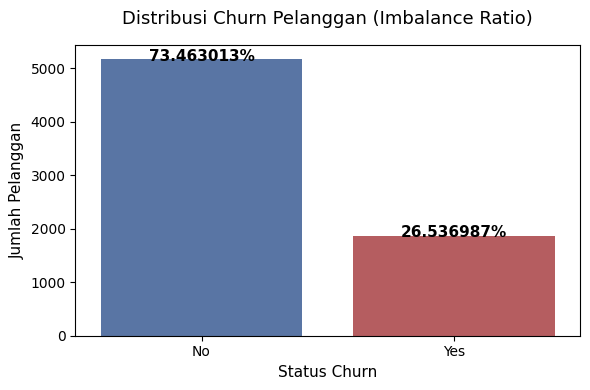

In [3]:
""" Distribusi Churn (Bar Chart Proporsi) """

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])

# Add percentaze label on the bar
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Distribusi Churn Pelanggan (Imbalance Ratio)', fontsize=13, pad=15)
plt.xlabel('Status Churn', fontsize=11)
plt.ylabel('Jumlah Pelanggan', fontsize=11)
plt.tight_layout()
plt.show()

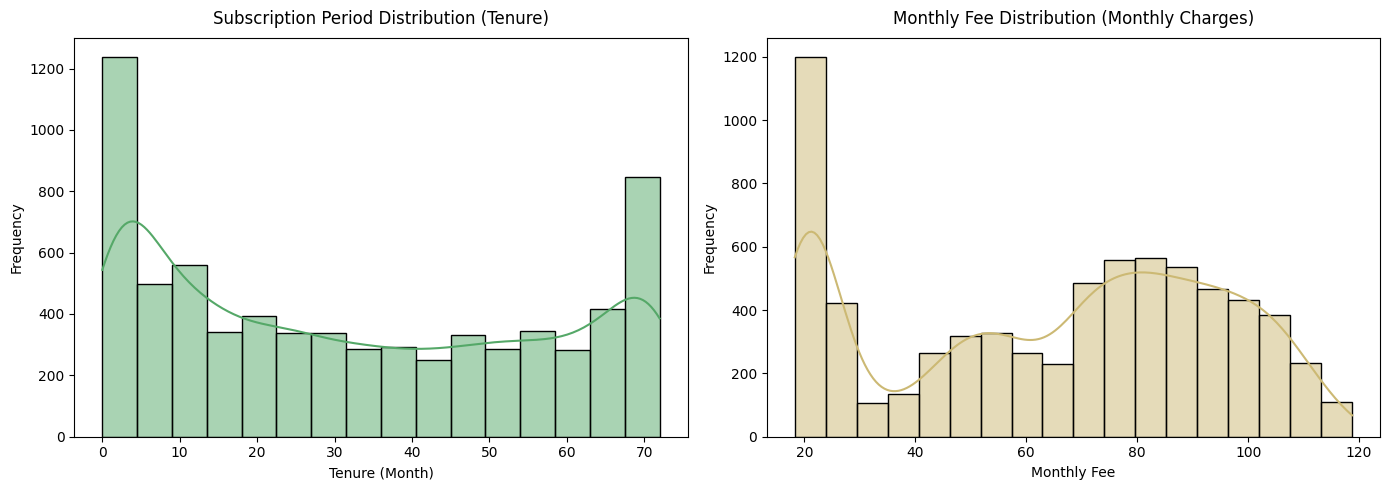

In [ ]:
""" Distribusi Tenure & Monthly Charges (Histogram & KDE) """
fig, axes =plt.subplots(1, 2, figsize=(14, 5))

# Plot Tenure
sns.histplot(data=df, x='tenure', kde=True, ax=axes[0], color='#55A868')
axes[0].set_title('Subscription Period Distribution (Tenure)', fontsize=12, pad=10)
axes[0].set_xlabel('Tenure (Month)')
axes[0].set_ylabel('Frequency')

# Plot Monthly Charges
sns.histplot(data=df, x='MonthlyCharges', kde=True, ax=axes[1], color='#CCB974')
axes[1].set_title('Monthly Fee Distribution (Monthly Charges)', fontsize=12, pad=10)
axes[1].set_xlabel('Monthly Fee')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Bivariate Analysis Plots
---

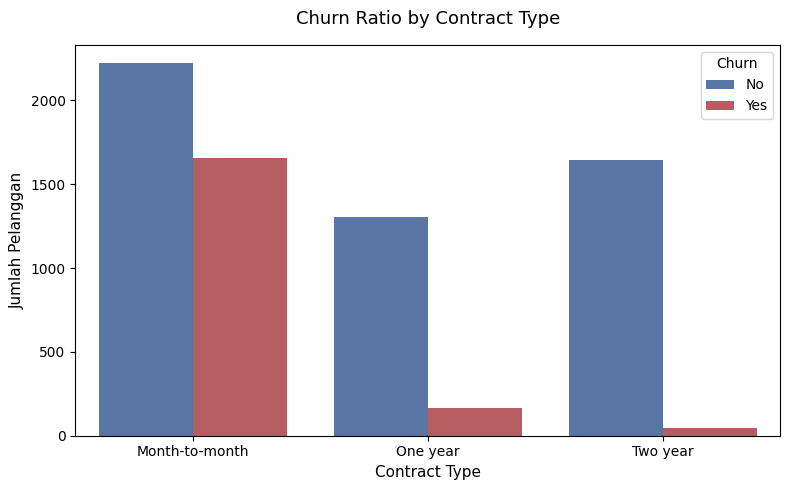

In [8]:
""" Churn vs Contract """

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'])

plt.title('Churn Ratio by Contract Type', fontsize=13, pad=15)
plt.xlabel('Contract Type', fontsize=11)
plt.ylabel('Jumlah Pelanggan', fontsize=11)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

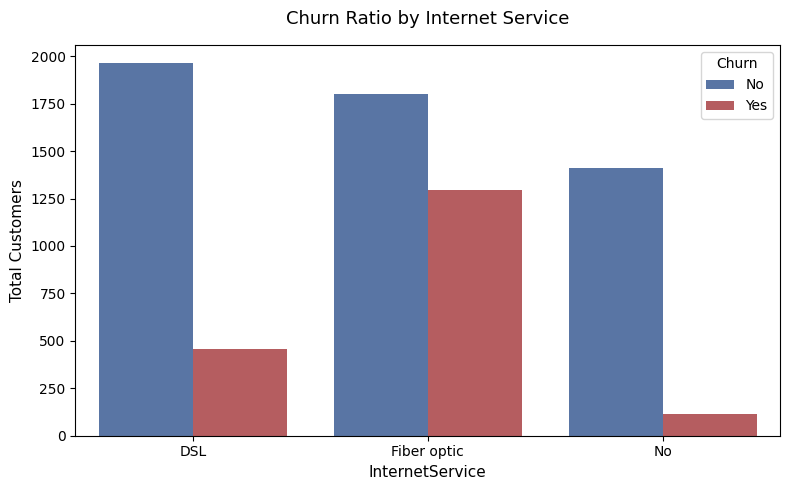

In [9]:
""" Churn vs Internet Service """

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#4C72B0', '#C44E52'])

plt.title('Churn Ratio by Internet Service', fontsize=13, pad=15)
plt.xlabel('InternetService', fontsize=11)
plt.ylabel('Total Customers', fontsize=11)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

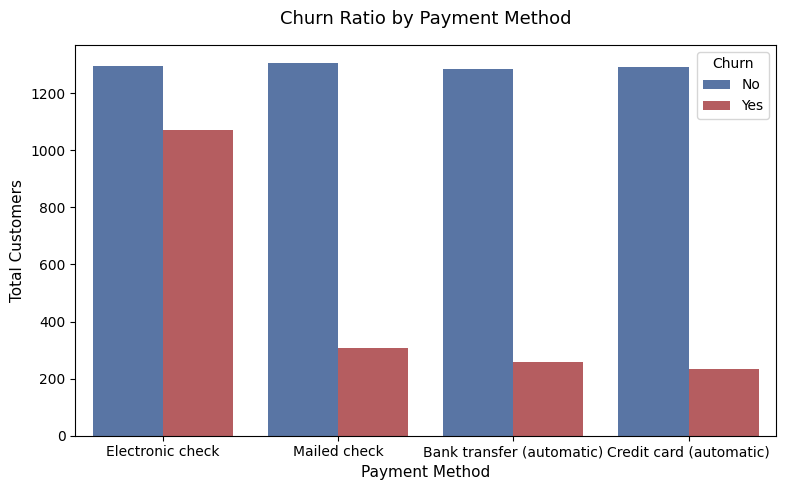

In [10]:
""" Churn vs Payment Method """

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#4C72B0', '#C44E52'])

plt.title('Churn Ratio by Payment Method', fontsize=13, pad=15)
plt.xlabel('Payment Method', fontsize=11)
plt.ylabel('Total Customers', fontsize=11)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Multivariate Analysis Plots
---

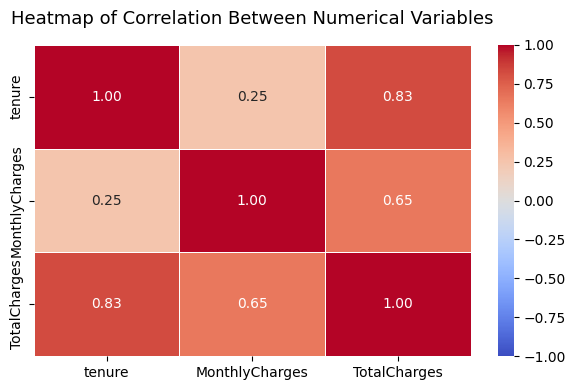

In [13]:
""" Heatmap Korelasi Variabel Numerik """

plt.figure(figsize=(6, 4))
matrix_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Heatmap of Correlation Between Numerical Variables', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

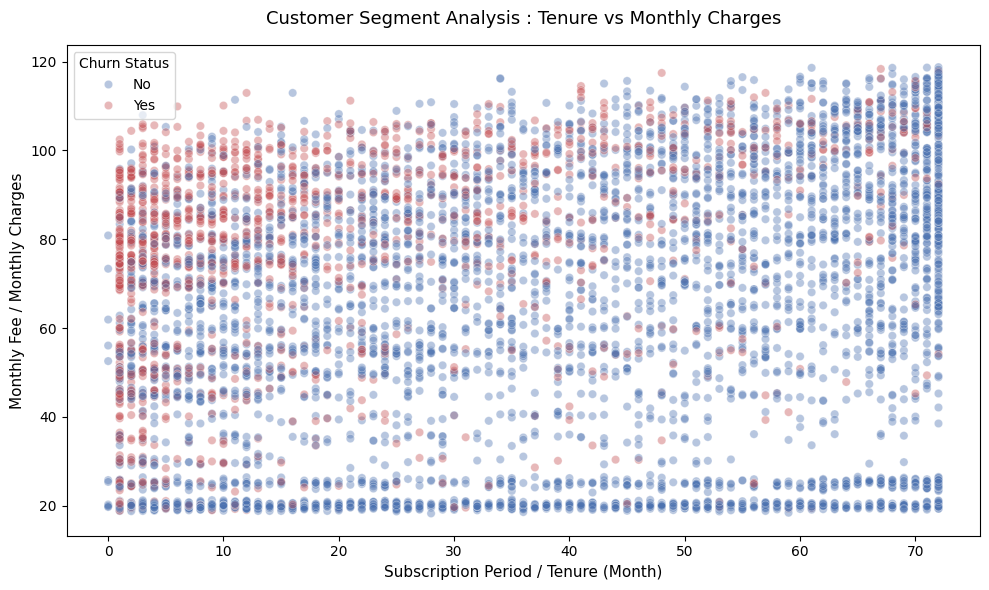

In [15]:
""" Segment Analysis (Scatter Plot: Tenure vs Monthly Charges) """

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=['#4C72B0', '#C44E52'])

plt.title('Customer Segment Analysis : Tenure vs Monthly Charges', fontsize=13, pad=15)
plt.xlabel('Subscription Period / Tenure (Month)', fontsize=11)
plt.ylabel('Monthly Fee / Monthly Charges', fontsize=11)
plt.legend(title='Churn Status')
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18808\2844882738.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(index='InternetService',


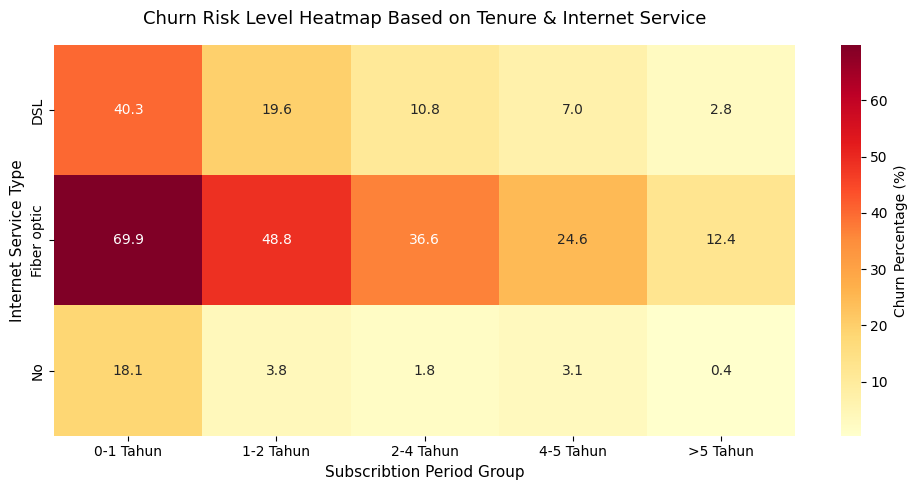

In [19]:
""" Pivot Heatmap (Rasio Churn Gabungan Tenure & Internet) """

plt.figure(figsize=(10, 5))

df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 60, 72],
                            labels=['0-1 Tahun', '1-2 Tahun', '2-4 Tahun', '4-5 Tahun','>5 Tahun'])

pivot_data = df.pivot_table(index='InternetService',
                            columns='tenure_group',
                            values='Churn',
                            aggfunc=lambda x: (x == 'Yes').sum() / len(x) * 100)

sns.heatmap(pivot_data, annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Churn Percentage (%)'})

plt.title('Churn Risk Level Heatmap Based on Tenure & Internet Service', fontsize=13, pad=15)
plt.xlabel('Subscribtion Period Group', fontsize=11)
plt.ylabel('Internet Service Type', fontsize=11)
plt.tight_layout()
plt.show()